In [91]:
# %% ─── Cell 1: Imports & Config ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import ast, math, random, warnings, os, pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

CFG = dict(
    # Item2Vec
    ITEM2VEC_DIM  = 32,   # kept small — only 295 items
    I2V_WINDOW    = 10,   # large window so all cart items see each other
    I2V_MIN_COUNT = 1,
    I2V_EPOCHS    = 100,   # more epochs for small vocab

    # Two-Tower
    EMB_DIM       = 64,
    HIDDEN_DIM    = 128,
    BATCH_SIZE    = 256,
    EPOCHS        = 60,
    LR            = 2e-4,
    WEIGHT_DECAY  = 1e-4,
    TEMPERATURE   = 0.3,   # slightly relaxed — real data is noisier
    DROPOUT       = 0.1,
    BCE_WEIGHT     = 1.0,  # changed: pure BCE
    INBATCH_WEIGHT = 0.0,
    TOP_K         = [1, 3],  # shown set size is 3, so K=1,3 is natural
    DEVICE        = "cuda" if torch.cuda.is_available() else "cpu",
)
print(f"Device : {CFG['DEVICE']}")


Device : cpu


In [92]:
# %% ─── Cell 2: Load Data ──────────────────────────────────────────────────────

BASE_DIR = os.path.abspath(os.path.join(os.getcwd()))

customers_df = pd.read_csv(BASE_DIR + "/Data Generation/Data/zomato_customers.csv")
menu_df      = pd.read_csv(BASE_DIR + "/Data Generation/Data/zomato_menu.csv")
orders_df    = pd.read_csv(BASE_DIR + "/Data Generation/Data/zomato_orders.csv")

# ── Parse string-encoded lists
def safe_parse(s):
    try:
        return ast.literal_eval(str(s))
    except Exception:
        return []

for col in ["Items Ordered ID", "Items Ordered Name",
            "Recommendation Shown ID", "Recommendation Shown Name"]:
    orders_df[col] = orders_df[col].apply(safe_parse)

# ── Parse cuisine/veg preference vectors from customers
customers_df["cuisine_pref_vec"] = customers_df["Cuisine Preference"].apply(safe_parse)
customers_df["veg_vec"]          = customers_df["Veg Nonveg Egg Preference"].apply(safe_parse)

# ── Parse order_time → hour
orders_df["hour"] = pd.to_datetime(
    orders_df["Order Time"]
).dt.hour

# ── Menu: item_id is already integer index 0–294
# Build fast lookup dicts
ITEM_META = menu_df.set_index("Item ID").to_dict("index")
# e.g. ITEM_META[60] = {"item_name":"Appam","cuisine":"South Indian","course":"mains","veg_type":"veg"}

print(f"Customers : {customers_df.shape}")
print(f"Menu      : {menu_df.shape}")
print(f"Orders    : {orders_df.shape}")
print(f"\nCuisines  : {menu_df.Cuisine.unique().tolist()}")
print(f"Courses   : {menu_df.Course.unique().tolist()}")
print(f"Veg types : {menu_df['Veg Type'].unique().tolist()}")

Customers : (2000, 13)
Menu      : (351, 12)
Orders    : (100000, 12)

Cuisines  : ['North Indian', 'South Indian', 'Biryani', 'Italian', 'Chinese', 'Fast Food', 'Healthy']
Courses   : ['mains', 'appetizers', 'complements', 'extras', 'desserts & beverages']
Veg types : ['veg', 'nonveg', 'egg']


In [93]:
customers_df["Income Bracket"] = pd.qcut(
    customers_df["avg_order_value"],
    q=[0, 0.3, 0.7, 1.0],   # 30% | 40% | 30%
    labels=["Low Income", "Middle Income", "High Income"]
)

In [ ]:
#Cell 2b

import numpy as np
# ── 1. Cuisine compatibility — pull all values down
CUISINE_COMPAT = {
    "North Indian" : {"North Indian": 0.28, "Biryani": 0.20, "default": 0.05},
    "South Indian" : {"South Indian": 0.28, "Healthy": 0.16, "default": 0.05},
    "Chinese"      : {"Chinese": 0.28, "Fast Food": 0.16, "default": 0.05},
    "Biryani"      : {"Biryani": 0.28, "North Indian": 0.18, "default": 0.05},
    "Italian"      : {"Italian": 0.28, "Fast Food": 0.14, "default": 0.05},
    "Fast Food"    : {"Fast Food": 0.28, "Italian": 0.14, "default": 0.05},
    "Healthy"      : {"Healthy": 0.28, "South Indian": 0.14, "default": 0.04},
}

# ── 2. Course completion — pull boosts down
COURSE_COMPLETION = {
    "missing_desserts & beverages" : 0.18,  # was 0.10 — strongest signal
    "missing_complements"          : 0.15,  # was 0.08
    "missing_appetizers"           : 0.06,  # was 0.05
    "missing_extras"               : 0.03,  # unchanged
}

def compute_acceptance_prob(customer_row, item_row, cart_item_ids, order_cuisine):
    """
    Acceptance probability conditioned on:
    1. Cuisine match between order and recommended item
    2. Veg preference match
    3. Cart completion (what courses are missing)
    4. User price sensitivity vs item price
    """
    base_prob = 0.15  # base acceptance rate

    # ── 1. Cuisine compatibility
    compat_map  = CUISINE_COMPAT.get(order_cuisine, {})
    item_cuisine = item_row["Cuisine"]
    cuisine_prob = compat_map.get(item_cuisine, compat_map.get("default", 0.15))
    base_prob    = cuisine_prob   # cuisine match dominates

    # ── 2. Veg preference alignment
    VEG_MULTIPLIER = {
        # (customer_dominant_pref, item_veg_type) → acceptance multiplier
        ("veg",    "veg")    : 1.40,   # strong match → boost
        ("veg",    "egg")    : 0.70,   # mild mismatch → moderate penalty
        ("veg",    "nonveg") : 0.35,   # hard mismatch → strong penalty
        ("nonveg", "veg")    : 0.85,   # slight mismatch → small penalty
        ("nonveg", "egg")    : 1.10,   # good match
        ("nonveg", "nonveg") : 1.30,   # strong match → boost
        ("egg",    "veg")    : 0.90,
        ("egg",    "egg")    : 1.20,
        ("egg",    "nonveg") : 1.10,
    }

    # Determine customer's dominant veg preference
    veg_vec     = customer_row["veg_vec"]   # [P(veg), P(nonveg), P(egg)]
    dom_idx     = int(np.argmax(veg_vec))
    dom_pref    = ["veg", "nonveg", "egg"][dom_idx]
    item_vtype  = item_row["Veg Type"]

    multiplier  = VEG_MULTIPLIER.get((dom_pref, item_vtype), 1.0)
    base_prob  *= multiplier 

    # ── 3. Cart completion boost
    cart_courses = set(
        menu_df.loc[menu_df['Item ID'].isin(cart_item_ids), "Course"].tolist()
    )
    item_course = item_row["Course"]
    if item_course not in cart_courses:
        boost = COURSE_COMPLETION.get(f"missing_{item_course}", 0.05)
        base_prob += boost   # boost for completing the meal

    # ── 4. Price sensitivity
    # budget users less likely to add extras, premium users more likely
    income = customer_row["Income Bracket"]
    if income == "high":
        base_prob += 0.04
    elif income == "low":
        base_prob -= 0.03

    return float(np.clip(base_prob, 0.02, 0.45))


# ── Apply to all orders
rng = np.random.default_rng(42)
new_added = {1: [], 2: [], 3: []}

for _, order_row in orders_df.iterrows():
    cid       = order_row["Customer ID"]
    shown_ids = order_row["Recommendation Shown ID"]
    cart      = order_row["Items Ordered ID"]
    cuisine   = order_row["Cuisine"]
    cust      = customers_df[customers_df['Customer ID'] == cid].iloc[0]

    for slot, iid in enumerate(shown_ids[:3], 1):
        if iid not in menu_df['Item ID'].values:
            new_added[slot].append(0)
            continue
        item  = menu_df[menu_df['Item ID'] == iid].iloc[0]
        prob  = compute_acceptance_prob(cust, item, cart, cuisine)
        label = int(rng.random() < prob)
        new_added[slot].append(label)

orders_df["Recommendation Added 1"] = new_added[1]
orders_df["Recommendation Added 2"] = new_added[2]
orders_df["Recommendation Added 3"] = new_added[3]

# ── Verify the new label distribution
print("New acceptance rates:")
for col in ["Recommendation Added 1","Recommendation Added 2","Recommendation Added 3"]:
    print(f"  {col}: {orders_df[col].mean()*100:.1f}%")

# Sanity check: veg users should accept veg items more
# (if this isn't true after regeneration, the logic has a bug)
veg_heavy_users = customers_df[
    customers_df["veg_vec"].apply(lambda x: x[0] > 0.7)  # strong veg preference
]["Customer ID"].tolist()

veg_item_ids = menu_df[menu_df['Veg Type'] == "veg"]["Item ID"].tolist()

veg_user_veg_item = examples_df[
    (examples_df['customer_id'].isin(veg_heavy_users)) &
    (examples_df.shown_item_id.isin(veg_item_ids))
]["label"].mean()

veg_user_nonveg_item = examples_df[
    (examples_df['customer_id'].isin(veg_heavy_users)) &
    (~examples_df.shown_item_id.isin(veg_item_ids))
]["label"].mean()

print(f"\nVeg users accepting veg items    : {veg_user_veg_item * 100:.1f}%")
print(f"Veg users accepting non-veg items: {veg_user_nonveg_item * 100:.1f}%")
print("First number should be meaningfully higher than second")

New acceptance rates:
  Recommendation Added 1: 32.6%
  Recommendation Added 2: 32.6%
  Recommendation Added 3: 32.4%

Veg users accepting veg items    : 32.9%
Veg users accepting non-veg items: 12.8%
↑ First number should be meaningfully higher than second


In [96]:
#Cell 2c

# Quick sanity check before proceeding
# Veg users should accept veg items more than non-veg items
# If this passes, the conditioned labels are working
veg_heavy_users = customers_df[
    customers_df["veg_vec"].apply(lambda x: x[0] > 0.7)
]["Customer ID"].tolist()

veg_item_ids    = menu_df[menu_df['Veg Type'] == "veg"]["Item ID"].tolist()

orders_exploded = orders_df.explode("Recommendation Shown ID")
orders_exploded["slot"] = orders_exploded.groupby("Order ID").cumcount()
orders_exploded["label"] = orders_exploded.apply(
    lambda r: r[f"Recommendation Added {r['slot']+1}"]
    if r["slot"] < 3 else 0, axis=1
)

veg_mask    = orders_exploded["Recommendation Shown ID"].isin(veg_item_ids)
veg_u_mask  = orders_exploded["Customer ID"].isin(veg_heavy_users)

print("Conditioned label sanity check:")
print(f"  Veg users + veg items    : {orders_exploded[veg_u_mask &  veg_mask]['label'].mean()*100:.1f}%")
print(f"  Veg users + non-veg items: {orders_exploded[veg_u_mask & ~veg_mask]['label'].mean()*100:.1f}%")
print(f"  Overall acceptance rate  : {orders_exploded['label'].mean()*100:.1f}%")
# First line should be noticeably higher than second
# Overall should be between 20–35%

Conditioned label sanity check:
  Veg users + veg items    : 42.1%
  Veg users + non-veg items: 17.4%
  Overall acceptance rate  : 32.5%


In [97]:
# %% ─── Cell 3: Data Quality Checks ───────────────────────────────────────────

# Recommendation acceptance rate per slot
for i, col in enumerate(["Recommendation Added 1","Recommendation Added 2","Recommendation Added 3"]):
    rate = orders_df[col].mean()
    print(f"Slot {i+1} acceptance rate: {rate:.3f} ({rate*100:.1f}%)")

# Overall positive rate
orders_df["any_accepted"] = (
    orders_df[["Recommendation Added 1","Recommendation Added 2","Recommendation Added 3"]].sum(axis=1) > 0
).astype(int)
print(f"\nOrders with ≥1 recommendation accepted : {orders_df['any_accepted'].mean()*100:.1f}%")

# Cart size distribution
orders_df["cart_size"] = orders_df["Items Ordered ID"].apply(len)
print(f"\nCart size distribution:")
print(orders_df["cart_size"].describe().to_string())

# Check that recommendation_shown_id always has 3 items
shown_lens = orders_df["Recommendation Shown ID"].apply(len)
print(f"\nRecommendation set size — always 3: {(shown_lens == 3).all()}")


Slot 1 acceptance rate: 0.326 (32.6%)
Slot 2 acceptance rate: 0.326 (32.6%)
Slot 3 acceptance rate: 0.324 (32.4%)

Orders with ≥1 recommendation accepted : 68.8%

Cart size distribution:
count    100000.000000
mean          5.029950
std           2.314564
min           2.000000
25%           3.000000
50%           5.000000
75%           7.000000
max           8.000000

Recommendation set size — always 3: True


In [98]:
# %% ─── Cell 4: Item2Vec — Cart Co-occurrence Embeddings ──────────────────────
#
# Sentences = items in each order's cart (items_ordered_id)
# All items in the same cart = positive context for each other
# Result: items frequently ordered together → similar embeddings
#
# Example expected behaviour:
#   Chicken Biryani ≈ Raita (always co-ordered)
#   Appam ≈ Sambar ≈ Curd Rice (South Indian meal)
#   Veg Dim Sum ≈ Chicken Noodles (Chinese co-occur)

try:
    from gensim.models import Word2Vec
    GENSIM_OK = True
except ImportError:
    GENSIM_OK = False
    print("gensim not installed. Run: pip install gensim")

# Build cart sentences: item ids as strings (gensim expects string tokens)
cart_sentences = [
    [str(iid) for iid in row]
    for row in orders_df["Items Ordered ID"]
    if len(row) > 1
]
print(f"Cart sentences : {len(cart_sentences):,}")
print(f"Sample sentence: {cart_sentences[0]}")

ALL_ITEM_IDS  = menu_df["Item ID"].tolist()        # 0 … 294
N_ITEMS       = len(ALL_ITEM_IDS)
item_id_enc   = LabelEncoder().fit(ALL_ITEM_IDS)   # item_id (int) → index (0-based)

if GENSIM_OK:
    print(f"\nTraining Item2Vec (vocab={N_ITEMS} items, dim={CFG['ITEM2VEC_DIM']})…")
    i2v = Word2Vec(
        sentences   = cart_sentences,
        vector_size = CFG["ITEM2VEC_DIM"],
        window      = CFG["I2V_WINDOW"],
        min_count   = CFG["I2V_MIN_COUNT"],
        sg          = 1,       # skip-gram
        negative    = 15,
        ns_exponent = 0.75,
        epochs      = CFG["I2V_EPOCHS"],
        seed        = SEED,
        workers     = 1,
    )
    print(f"Item2Vec trained. Vocab covered: {len(i2v.wv)}/{N_ITEMS}")

    # Sanity check — nearest neighbours for a few items
    print("\nItem2Vec nearest neighbours:")
    for probe_id in [84, 60, 188]:   # Chicken Biryani, Appam, Veg Dim Sum
        token = str(probe_id)
        if token in i2v.wv:
            name  = ITEM_META[probe_id]["item_name"]
            simil = i2v.wv.most_similar(token, topn=4)
            print(f"  [{name}] →", [(ITEM_META[int(t)]["item_name"], f"{s:.3f}") for t, s in simil])
else:
    i2v = None

gensim not installed. Run: pip install gensim
Cart sentences : 100,000
Sample sentence: ['290', '297', '275']


In [99]:
# %% ─── Cell 5: Build Item2Vec Weight Matrix ───────────────────────────────────

item2vec_matrix = np.zeros((N_ITEMS, CFG["ITEM2VEC_DIM"]), dtype = np.float32)
covered = 0

if i2v is not None:
    for iid in ALL_ITEM_IDS:
        idx   = item_id_enc.transform([iid])[0]
        token = str(iid)
        if token in i2v.wv:
            item2vec_matrix[idx] = i2v.wv[token]
            covered += 1

print(f"Item2Vec coverage: {covered}/{N_ITEMS} ({100*covered/ N_ITEMS:.1f}%)")

# L2-normalise rows
norms = np.linalg.norm(item2vec_matrix, axis=1, keepdims = True)
norms[norms == 0] = 1.0
item2vec_matrix_normed = item2vec_matrix / norms
print(f"Embedding matrix shape: {item2vec_matrix_normed.shape}")

Item2Vec coverage: 0/351 (0.0%)
Embedding matrix shape: (351, 32)


In [100]:
# %% ─── Cell 6: Categorical Encoders ──────────────────────────────────────────

# ── Menu-level encoders
cuisine_enc = LabelEncoder().fit(menu_df["Cuisine"])
course_enc  = LabelEncoder().fit(menu_df["Course"])
vegtype_enc = LabelEncoder().fit(menu_df["Veg Type"])

# ── Customer-level encoders
city_enc            = LabelEncoder().fit(customers_df["City"])
income_enc          = LabelEncoder().fit(customers_df["Income Bracket"])
app_usage_enc       = LabelEncoder().fit(customers_df["App Usage Frequency"])

# ── Temporal
MEAL_TIME_MAP = {
    "breakfast": 0,   # 5–10
    "lunch"    : 1,   # 11–15
    "snack"    : 2,   # 16–18
    "dinner"   : 3,   # 19–22
    "late"     : 4,   # 23–4
}
def hour_to_mealtime(h):
    if   5  <= h <= 10: return "breakfast"
    elif 11 <= h <= 15: return "lunch"
    elif 16 <= h <= 18: return "snack"
    elif 19 <= h <= 22: return "dinner"
    else:               return "late"

orders_df["meal_time"] = orders_df["hour"].apply(hour_to_mealtime)

VOCAB = {
    "n_items"    : N_ITEMS,
    "n_cuisines" : len(cuisine_enc.classes_),
    "n_courses"  : len(course_enc.classes_),
    "n_vegtypes" : len(vegtype_enc.classes_),
    "n_cities"   : len(city_enc.classes_),
    "n_incomes"  : len(income_enc.classes_),
    "n_appusage" : len(app_usage_enc.classes_),
    "n_mealtimes": len(MEAL_TIME_MAP),
}
print("Vocabulary sizes:", VOCAB)

# ── Price scaler (avg_per_item_value as proxy for user spend level)
price_scaler = StandardScaler()
customers_df['avg_per_item_value'] = customers_df['avg_order_value']/ customers_df['avg_order_items']
price_scaler.fit(customers_df[["avg_per_item_value"]])

Vocabulary sizes: {'n_items': 351, 'n_cuisines': 7, 'n_courses': 5, 'n_vegtypes': 3, 'n_cities': 4, 'n_incomes': 3, 'n_appusage': 3, 'n_mealtimes': 5}


StandardScaler()

In [101]:
# %% ─── Cell 7: Feature Lookup Tables ─────────────────────────────────────────

# ── Item feature lookup (precomputed, O(1) at training time)
menu_enc = menu_df.copy()
menu_enc["item_idx"]    = item_id_enc.transform(menu_enc["Item ID"])
menu_enc["cuisine_idx"] = cuisine_enc.transform(menu_enc["Cuisine"])
menu_enc["course_idx"]  = course_enc.transform(menu_enc["Course"])
menu_enc["vegtype_idx"] = vegtype_enc.transform(menu_enc["Veg Type"])
menu_enc["is_veg"]      = (menu_enc["Veg Type"] == "veg").astype(float)
menu_enc["is_nonveg"]   = (menu_enc["Veg Type"] == "nonveg").astype(float)
ITEM_LOOKUP = menu_enc.set_index("Item ID")

# ── Customer feature lookup
cust_enc = customers_df.copy()
cust_enc["city_idx"]       = city_enc.transform(cust_enc["City"])
cust_enc["income_idx"]     = income_enc.transform(cust_enc["Income Bracket"])
cust_enc["appusage_idx"]   = app_usage_enc.transform(cust_enc["App Usage Frequency"])
cust_enc["price_scaled"]   = price_scaler.transform(cust_enc[["avg_per_item_value"]])
cust_enc["avg_items_norm"] = cust_enc["avg_order_items"] / 10.0
CUST_LOOKUP = cust_enc.set_index("Customer ID")

# ── Cart embedding: mean-pool Item2Vec vectors of cart items
ZERO_VEC = np.zeros(CFG["ITEM2VEC_DIM"], dtype=np.float32)

def get_cart_embedding(item_id_list: list) -> np.ndarray:
    """
    Semantic cart state: mean-pool Item2Vec vectors.
    [Chicken Biryani, Raita] → vector in 'spicy Indian' region
    [Appam, Sambar]          → vector in 'South Indian' region
    """
    vecs = []
    for iid in item_id_list:
        idx = item_id_enc.transform([iid])[0] if iid in ALL_ITEM_IDS else None
        if idx is not None:
            vecs.append(item2vec_matrix_normed[idx])
    return np.mean(vecs, axis=0).astype(np.float32) if vecs else ZERO_VEC

# Quick test
test_cart = orders_df["Items Ordered ID"].iloc[0]
print(f"Test cart: {test_cart}")
print(f"Cart emb : shape={get_cart_embedding(test_cart).shape}, "
      f"norm={np.linalg.norm(get_cart_embedding(test_cart)):.3f}")


Test cart: [290, 297, 275]
Cart emb : shape=(32,), norm=0.000


In [102]:
zero_count = sum(
    1 for emb in examples_df["cart_emb"]
    if np.linalg.norm(emb) < 0.01
)
print(f"Zero/near-zero cart embeddings: {zero_count}/{len(examples_df)} "
      f"({100*zero_count/len(examples_df):.1f}%)")

# Also check a few
for i in [0, 100, 500]:
    emb = examples_df["cart_emb"].iloc[i]
    print(f"Row {i}: norm={np.linalg.norm(emb):.3f}, sample={emb[:5]}")

Zero/near-zero cart embeddings: 300000/300000 (100.0%)
Row 0: norm=0.000, sample=[0. 0. 0. 0. 0.]
Row 100: norm=0.000, sample=[0. 0. 0. 0. 0.]
Row 500: norm=0.000, sample=[0. 0. 0. 0. 0.]


In [103]:
# %% ─── Cell 8: Build Training Examples ─────────────────────────────────────────
# KEY ADVANTAGE OF THIS DATA over synthetic next-item pairs:
#
#   Each order has up to 3 shown recommendations with explicit accept/reject labels.
#   This gives us EXPOSURE-AWARE training:
#       label=1 → item was shown AND accepted (true positive)
#       label=0 → item was shown AND rejected (hard negative — same context!)
#
#   Hard negatives = items shown in same context but not accepted.
#   This is vastly better than random negatives because the model learns
#   the *discriminating* signal within the same meal/cuisine/context.
#
# Training example structure:
#   Query  = customer features + cart embedding (items_ordered_id)
#   Item   = one of the 3 recommended items
#   Label  = recommendation_added_{i} ∈ {0, 1}

def build_training_examples(orders_df, cust_lookup, item_lookup):
    rows = []
    added_cols = ["Recommendation Added 1", "Recommendation Added 2", "Recommendation Added 3"]

    for _, row in orders_df.iterrows():
        cid       = row["Customer ID"]
        cart      = row["Items Ordered ID"]
        shown_ids = row["Recommendation Shown ID"]
        hour      = int(row["hour"])
        meal_time = row["meal_time"]

        # Must have exactly 3 shown recommendations
        if len(shown_ids) != 3:
            continue

        # Precompute cart embedding once per order
        cart_emb     = get_cart_embedding(cart)
        cart_total = sum(
            ITEM_META.get(i, {}).get("price", 0)
            for i in cart
        )
        cart_size    = len(cart)

        for slot, (shown_id, add_col) in enumerate(zip(shown_ids, added_cols)):
            label = int(row[add_col])

            # Skip if shown item not in menu
            if shown_id not in ITEM_META:
                continue

            rows.append({
                "customer_id"   : cid,
                "shown_item_id" : shown_id,
                "label"         : label,
                "cart_emb"      : cart_emb,
                "cart_size"     : cart_size,
                "cart_item_ids" : cart, 
                "hour"          : hour,
                "meal_time"     : meal_time,
                "slot"          : slot,           # position in rail (0,1,2)
            })

    return pd.DataFrame(rows)

print("Building training examples…")
examples_df = build_training_examples(orders_df, CUST_LOOKUP, ITEM_LOOKUP)
print(f"Total examples : {len(examples_df):,}")
print(f"Positive rate  : {examples_df['label'].mean()*100:.1f}%")
print(f"Positives      : {examples_df['label'].sum():,}")
print(f"Negatives      : {(examples_df['label']==0).sum():,}")



Building training examples…
Total examples : 300,000
Positive rate  : 32.5%
Positives      : 97,633
Negatives      : 202,367


In [75]:
# After loading customers
sample = CUST_LOOKUP.iloc[0]
print("cuisine_pref_vec:", sample["cuisine_pref_vec"])
print("type:", type(sample["cuisine_pref_vec"]))
print("len:", len(sample["cuisine_pref_vec"]))
# Should be a list of 7 floats. If it's a string → parsing failed

cuisine_pref_vec: [0.28, 0.08, 0.32, 0.1, 0.12, 0.08, 0.02]
type: <class 'list'>
len: 7


In [76]:
item_accept_rates = (
    examples_df.groupby("shown_item_id")["label"]
    .agg(["mean","count"])
    .sort_values("mean", ascending = False)
)
print(item_accept_rates.head(10))
print(item_accept_rates.tail(10))
# If some items have acceptance rate ~1.0 or ~0.0 across all users
# → the signal is item popularity, not personalization
# → TTE is the wrong model for this

                   mean  count
shown_item_id                 
75             0.465116    344
70             0.433333    360
270            0.426343    577
62             0.425806    310
115            0.422348    528
9              0.420701    599
65             0.416667    336
127            0.411043    489
231            0.410000    300
186            0.409736    493
                   mean  count
shown_item_id                 
178            0.139059    489
201            0.135974    934
199            0.132017    962
197            0.131929    902
271            0.131886    599
275            0.130282    568
182            0.125257    487
188            0.117526    485
184            0.112033    482
180            0.108796    432


In [79]:
# Pick one frequently shown item
top_item = examples_df["shown_item_id"].value_counts().index[0]
subset   = examples_df[examples_df["shown_item_id"] == top_item]
print(f"Item {top_item} shown {len(subset)} times, "
      f"accepted {subset['label'].mean()*100:.1f}% of the time")
print("Unique customers:", subset["customer_id"].nunique())
print("Does label vary by customer?")
print(subset.groupby("customer_id")["label"].mean().describe())

Item 85 shown 2536 times, accepted 18.3% of the time
Unique customers: 1219
Does label vary by customer?
count    1219.000000
mean        0.190562
std         0.325710
min         0.000000
25%         0.000000
50%         0.000000
75%         0.333333
max         1.000000
Name: label, dtype: float64


In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Build flat feature matrix — no embeddings, just raw signals
feat_rows = []
for _, row in examples_df.iterrows():
    iid = row["shown_item_id"]
    cid = row["customer_id"]
    it  = ITEM_LOOKUP.loc[iid] if iid in ITEM_LOOKUP.index else ITEM_LOOKUP.iloc[0]
    c   = CUST_LOOKUP.loc[cid] if cid in CUST_LOOKUP.index else CUST_LOOKUP.iloc[0]
    feat_rows.append({
        "item_cuisine_idx" : int(it["cuisine_idx"]),
        "item_course_idx"  : int(it["course_idx"]),
        "item_is_veg"      : float(it["is_veg"]),
        "cart_size"        : row["cart_size"],
        "hour"             : row["hour"],
        "user_income"      : int(c["income_idx"]),
        "label"            : row["label"],
    })

feat_df = pd.DataFrame(feat_rows)
X = feat_df.drop("label", axis=1).values
y = feat_df["label"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.2,
                                            random_state = SEED, stratify = y)

lr = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
lr_auc = roc_auc_score(y_te, lr.predict_proba(X_te)[:,1])
print(f"Logistic Regression AUC (no embeddings): {lr_auc:.4f}")

Logistic Regression AUC (no embeddings): 0.5486


In [107]:
# %% ─── Cell 9: Train / Test Split ─────────────────────────────────────────────
#
# Random 80/20 split (no timestamp in orders, so can't do temporal split).
# For production: use order_id range to simulate temporal split.

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    examples_df, test_size=0.20, random_state=SEED, stratify=examples_df["label"]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):,}  positives={train_df['label'].mean()*100:.1f}%")
print(f"Test  : {len(test_df):,}   positives={test_df['label'].mean()*100:.1f}%")


Train : 240,000  positives=32.5%
Test  : 60,000   positives=32.5%


In [108]:
# %% ─── Cell 10: PyTorch Dataset ───────────────────────────────────────────────

class CsaoDataset(Dataset):
    """
    Each example → (user_feats, cart_feats, item_feats, label)

    user_feats:
        city_idx, income_idx, appusage_idx     (categorical)
        cuisine_pref_vec (7-dim)               (dense user preference)
        veg_vec (3-dim)                        (dense dietary preference)
        price_scaled, avg_items_norm           (scalars)

    cart_feats:
        cart_emb (ITEM2VEC_DIM)               (semantic cart state)
        cart_size                              (scalar)
        meal_time_idx, hour_sin, hour_cos      (temporal)

    item_feats:
        item_idx, cuisine_idx, course_idx,
        vegtype_idx                            (categorical)
        is_veg, is_nonveg                      (binary scalars)
    """
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        cid = row["customer_id"]
        iid = row["shown_item_id"]

        # What courses are already in the cart
        cart_courses = set(
            ITEM_META.get(iid, {}).get("course", "") 
            for iid in row["cart_item_ids"]
        )
        shown_course         = ITEM_META.get(iid, {}).get("course", "")
        course_already_present = shown_course in cart_courses

        # ── Customer features
        c = CUST_LOOKUP.loc[cid] if cid in CUST_LOOKUP.index else CUST_LOOKUP.iloc[0]
        user_feats = {
            "city_idx"       : int(c["city_idx"]),
            "income_idx"     : int(c["income_idx"]),
            "appusage_idx"   : int(c["appusage_idx"]),
            "cuisine_pref"   : np.array(c["cuisine_pref_vec"], dtype=np.float32),
            "veg_vec"        : np.array(c["veg_vec"],          dtype=np.float32),
            "price_scaled"   : float(c["price_scaled"]),
            "avg_items_norm" : float(c["avg_items_norm"]),
        }

        # ── Cart features — including course completion flags
        cart_feats = {
            "cart_emb"         : row["cart_emb"].astype(np.float32),
            "cart_size"        : float(row["cart_size"]) / 10.0,
            "meal_time_idx"    : float(MEAL_TIME_MAP.get(row["meal_time"], 0)),
            "hour_sin"         : float(np.sin(2 * np.pi * row["hour"] / 24)),
            "hour_cos"         : float(np.cos(2 * np.pi * row["hour"] / 24)),
            "has_mains"        : float("mains"                in cart_courses),
            "has_appetizers"   : float("appetizers"           in cart_courses),
            "has_complements"  : float("complements"          in cart_courses),
            "has_desserts_bev" : float("desserts & beverages" in cart_courses),
            "course_missing"   : float(not course_already_present),
        }

        # ── Item features
        it = ITEM_LOOKUP.loc[iid] if iid in ITEM_LOOKUP.index else ITEM_LOOKUP.iloc[0]
        item_feats = {
            "item_idx"    : int(it["item_idx"]),
            "cuisine_idx" : int(it["cuisine_idx"]),
            "course_idx"  : int(it["course_idx"]),
            "vegtype_idx" : int(it["vegtype_idx"]),
            "is_veg"      : float(it["is_veg"]),
            "is_nonveg"   : float(it["is_nonveg"]),
        }

        return user_feats, cart_feats, item_feats, float(row["label"])


def collate_fn(batch):
    uf_keys  = batch[0][0].keys()
    cf_keys  = batch[0][1].keys()
    itf_keys = batch[0][2].keys()

    def stack(lst, dtype):
        arr = np.stack(lst) if isinstance(lst[0], np.ndarray) else np.array(lst)
        return torch.tensor(arr, dtype=dtype)

    user_batch = {}
    for k in uf_keys:
        vals = [b[0][k] for b in batch]
        if k in ("cuisine_pref", "veg_vec"):
            user_batch[k] = stack(vals, torch.float32)
        elif k in ("city_idx","income_idx","appusage_idx"):
            user_batch[k] = torch.tensor(vals, dtype=torch.long)
        else:
            user_batch[k] = torch.tensor(vals, dtype=torch.float32)

    cart_batch = {}
    for k in cf_keys:
        vals = [b[1][k] for b in batch]
        if k == "cart_emb":
            cart_batch[k] = stack(vals, torch.float32)
        else:
            cart_batch[k] = torch.tensor(vals, dtype=torch.float32)

    item_batch = {}
    for k in itf_keys:
        vals = [b[2][k] for b in batch]
        if k in ("item_idx","cuisine_idx","course_idx","vegtype_idx"):
            item_batch[k] = torch.tensor(vals, dtype=torch.long)
        else:
            item_batch[k] = torch.tensor(vals, dtype=torch.float32)

    labels = torch.tensor([b[3] for b in batch], dtype=torch.float32)
    return user_batch, cart_batch, item_batch, labels


train_ds     = CsaoDataset(train_df)
test_ds      = CsaoDataset(test_df)
train_loader = DataLoader(train_ds, batch_size=CFG["BATCH_SIZE"], shuffle=True,
                          num_workers=0, collate_fn=collate_fn, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["BATCH_SIZE"], shuffle=False,
                          num_workers=0, collate_fn=collate_fn, drop_last=False)
print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")


Train batches: 937  |  Test batches: 235


In [ ]:
# %% ─── Cell 11: Two-Tower Model ───────────────────────────────────────────────

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, out_dim),
        )
    def forward(self, x): return self.net(x)


class QueryTower(nn.Module):
    """
    Encodes (customer + cart state) → 64-dim query embedding.

    User side:
        3 categorical embeddings (city, income, app_usage)
        cuisine_pref_vec (7-dim probability vector — used as-is, no encoding)
        veg_vec (3-dim probability vector)
        2 scalars (price_scaled, avg_items_norm)

    Cart side:
        cart_emb (ITEM2VEC_DIM) → projected to EMB_DIM  ← semantic cart state
        3 temporal scalars (meal_time, hour_sin, hour_cos)
    """
    def __init__(self, vocab, cfg, item2vec_dim):
        super().__init__()
        E   = cfg["EMB_DIM"] // 4
        D   = cfg["EMB_DIM"]
        H   = cfg["HIDDEN_DIM"]
        P   = cfg["DROPOUT"]

        # Categorical embeddings
        self.emb_city     = nn.Embedding(vocab["n_cities"],   E)
        self.emb_income   = nn.Embedding(vocab["n_incomes"],  E)
        self.emb_appusage = nn.Embedding(vocab["n_appusage"], E)

        # Dense projection for cuisine_pref (7) and veg_vec (3)
        self.cuisine_proj = nn.Linear(7, E)
        self.veg_proj     = nn.Linear(3, E)

        # Cart embedding projection
        self.cart_proj = nn.Sequential(
            nn.Linear(item2vec_dim, D),
            nn.GELU(),
        )

        # Total MLP input:
        # 3 categ embs×E + cuisine_proj(E) + veg_proj(E) + 2 user scalars
        # + cart_proj(D) + 3 temporal scalars
        mlp_in = 5 * E + 2 + D + 3 + 5
        self.mlp = MLP(mlp_in, H, D, P)

    def forward(self, u, c):
        e_city     = self.emb_city    (u["city_idx"])       # (B, E)
        e_income   = self.emb_income  (u["income_idx"])
        e_appusage = self.emb_appusage(u["appusage_idx"])

        # Dense user preference vectors (already meaningful distributions)
        e_cuisine_pref = self.cuisine_proj(u["cuisine_pref"])  # (B, E)
        e_veg          = self.veg_proj    (u["veg_vec"])       # (B, E)

        user_scalars = torch.stack([
            u["price_scaled"], u["avg_items_norm"]
        ], dim=1)                                              # (B, 2)

        # Semantic cart state
        cart_proj = self.cart_proj(c["cart_emb"])             # (B, D)

        temporal = torch.stack([
            c["meal_time_idx"],
            c["hour_sin"],
            c["hour_cos"],
        ], dim=1)                                              # (B, 3)

        course_flags = torch.stack([
            c["has_mains"],
            c["has_appetizers"],
            c["has_complements"],
            c["has_desserts_bev"],
            c["course_missing"],
        ], dim=1)                                              # (B, 5)

        x = torch.cat([
            e_city, e_income, e_appusage,
            e_cuisine_pref, e_veg,
            user_scalars,
            cart_proj,
            temporal,
            course_flags,                                      # ← add this line
        ], dim=1)
        return F.normalize(self.mlp(x), p=2, dim=1)


class ItemTower(nn.Module):
    """
    Encodes item → 64-dim item embedding.
    Initialised from Item2Vec (cart co-occurrence structure), fine-tuned by TTE.
    """
    def __init__(self, vocab, cfg, item2vec_weights: np.ndarray):
        super().__init__()
        E = cfg["EMB_DIM"] // 4
        D = cfg["EMB_DIM"]
        H = cfg["HIDDEN_DIM"]
        P = cfg["DROPOUT"]

        # Item embedding — seeded from Item2Vec
        # Project from ITEM2VEC_DIM (32) → EMB_DIM (64) before feeding to MLP
        i2v_dim = item2vec_weights.shape[1]
        self.emb_item    = nn.Embedding.from_pretrained(
            torch.FloatTensor(item2vec_weights), freeze=False
        )
        self.item_proj   = nn.Linear(i2v_dim, D)   # 32 → 64

        self.emb_cuisine = nn.Embedding(vocab["n_cuisines"], E)
        self.emb_course  = nn.Embedding(vocab["n_courses"],  E)
        self.emb_vegtype = nn.Embedding(vocab["n_vegtypes"], E)

        # Input: item_proj(D) + 3 categ embs×E + 2 binary scalars
        mlp_in = D + 3 * E + 2
        self.mlp = MLP(mlp_in, H, D, P)

    def forward(self, f):
        e_item    = self.item_proj(self.emb_item(f["item_idx"]))  # (B, D)
        e_cuisine = self.emb_cuisine(f["cuisine_idx"])             # (B, E)
        e_course  = self.emb_course (f["course_idx"])
        e_vegtype = self.emb_vegtype(f["vegtype_idx"])

        scalars = torch.stack([f["is_veg"], f["is_nonveg"]], dim=1)  # (B, 2)

        x = torch.cat([e_item, e_cuisine, e_course, e_vegtype, scalars], dim=1)
        return F.normalize(self.mlp(x), p=2, dim=1)


class TwoTowerModel(nn.Module):
    """
    Training mode: binary cross-entropy on dot-product score (we have real labels).
    Inference mode: dot-product similarity → ranked list.

    Note: We use BCE rather than InfoNCE because we have explicit 0/1 labels
    from the recommendation exposure data — not just 'next-item' positives.
    Both in-batch InfoNCE and point-wise BCE are supported.
    """
    def __init__(self, vocab, cfg, item2vec_weights):
        super().__init__()
        self.temperature = cfg["TEMPERATURE"]
        self.query_tower = QueryTower(vocab, cfg, item2vec_dim=cfg["ITEM2VEC_DIM"])
        self.item_tower  = ItemTower (vocab, cfg, item2vec_weights)

    def forward(self, u, c, f):
        q = self.query_tower(u, c)   # (B, D)
        i = self.item_tower(f)       # (B, D)
        return q, i

    def pointwise_score(self, q, i):
        """Dot product similarity (cosine since both L2-normalised)."""
        return (q * i).sum(dim=1)                    # (B,)

    def bce_loss(self, q, i, labels):
        scores     = self.pointwise_score(q, i) / self.temperature
        pos_weight = torch.tensor([2.4]).to(scores.device)
        return F.binary_cross_entropy_with_logits(scores, labels, pos_weight=pos_weight)

    def inbatch_loss(self, q, i):
        """In-batch InfoNCE — used as auxiliary loss for embedding quality."""
        logits = torch.matmul(q, i.T) / self.temperature
        labels = torch.arange(logits.size(0), device=logits.device)
        return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2


model    = TwoTowerModel(VOCAB, CFG, item2vec_matrix_normed).to(CFG["DEVICE"])
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(model)

Model parameters: 75,952
TwoTowerModel(
  (query_tower): QueryTower(
    (emb_city): Embedding(4, 16)
    (emb_income): Embedding(3, 16)
    (emb_appusage): Embedding(3, 16)
    (cuisine_proj): Linear(in_features=7, out_features=16, bias=True)
    (veg_proj): Linear(in_features=3, out_features=16, bias=True)
    (cart_proj): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): GELU(approximate='none')
    )
    (mlp): MLP(
      (net): Sequential(
        (0): Linear(in_features=154, out_features=128, bias=True)
        (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.1, inplace=False)
        (4): Linear(in_features=128, out_features=64, bias=True)
        (5): GELU(approximate='none')
        (6): Dropout(p=0.05, inplace=False)
        (7): Linear(in_features=64, out_features=64, bias=True)
      )
    )
  )
  (item_tower): ItemTower(
    (emb_item): Embedding(351, 32)
    (item_p

In [110]:
# %% ─── Cell 12: Training ──────────────────────────────────────────────────────

optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"]
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["EPOCHS"], eta_min=1e-5
)

BCE_WEIGHT     = 1.0
INBATCH_WEIGHT = 0.0

def to_device(d, dev):
    return {k: v.to(dev) for k, v in d.items()}

# ── Early stopping state
OUT          = "/mnt/user-data/outputs"
best_auc     = 0.0
patience     = 8
no_improve   = 0

train_losses, val_losses = [], []

for epoch in range(1, CFG["EPOCHS"] + 1):
    # ── Train
    model.train()
    ep_bce, ep_inb, ep_total = 0.0, 0.0, 0.0
    for user_b, cart_b, item_b, labels in train_loader:
        user_b  = to_device(user_b, CFG["DEVICE"])
        cart_b  = to_device(cart_b, CFG["DEVICE"])
        item_b  = to_device(item_b, CFG["DEVICE"])
        labels  = labels.to(CFG["DEVICE"])

        optimizer.zero_grad()
        q, i = model(user_b, cart_b, item_b)

        bce_loss  = model.bce_loss(q, i, labels)
        inb_loss  = model.inbatch_loss(q, i)
        loss      = BCE_WEIGHT * bce_loss + INBATCH_WEIGHT * inb_loss

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        ep_bce   += bce_loss.item()
        ep_inb   += inb_loss.item()
        ep_total += loss.item()

    scheduler.step()
    avg_bce   = ep_bce   / len(train_loader)
    avg_inb   = ep_inb   / len(train_loader)
    avg_total = ep_total / len(train_loader)
    train_losses.append(avg_total)

    # ── Validation
    if epoch % 4 == 0 or epoch == CFG["EPOCHS"]:
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []
        with torch.no_grad():
            for user_b, cart_b, item_b, labels in test_loader:
                user_b = to_device(user_b, CFG["DEVICE"])
                cart_b = to_device(cart_b, CFG["DEVICE"])
                item_b = to_device(item_b, CFG["DEVICE"])
                labels = labels.to(CFG["DEVICE"])
                q, i   = model(user_b, cart_b, item_b)
                val_loss += model.bce_loss(q, i, labels).item()
                scores   = model.pointwise_score(q, i).cpu().numpy()
                val_preds.extend(scores.tolist())
                val_labels.extend(labels.cpu().numpy().tolist())

        avg_val = val_loss / len(test_loader)
        val_auc = roc_auc_score(val_labels, val_preds)
        val_losses.append((epoch, avg_val))

        # ── Early stopping check
        if val_auc > best_auc:
            best_auc   = val_auc
            no_improve = 0
            torch.save(model.state_dict(), f"tte_best_model.pt")
            print(f"Epoch {epoch:3d} | BCE={avg_bce:.4f}  InBatch={avg_inb:.4f}  "
                  f"Total={avg_total:.4f} | Val={avg_val:.4f}  AUC={val_auc:.4f}  ← best")
        else:
            no_improve += 1
            print(f"Epoch {epoch:3d} | BCE={avg_bce:.4f}  InBatch={avg_inb:.4f}  "
                  f"Total={avg_total:.4f} | Val={avg_val:.4f}  AUC={val_auc:.4f}  "
                  f"(no improve {no_improve}/{patience})")
            if no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch}.")
                break
    else:
        print(f"Epoch {epoch:3d} | BCE={avg_bce:.4f}  InBatch={avg_inb:.4f}  Total={avg_total:.4f}")

# ── Load best weights before inference / evaluation
model.load_state_dict(torch.load("tte_best_model.pt"))
print(f"\nTraining complete. Best AUC: {best_auc:.4f}")

Epoch   1 | BCE=0.9849  InBatch=5.6095  Total=0.9849
Epoch   2 | BCE=0.9751  InBatch=5.6330  Total=0.9751
Epoch   3 | BCE=0.9732  InBatch=5.6376  Total=0.9732
Epoch   4 | BCE=0.9715  InBatch=5.6401  Total=0.9715 | Val=0.9736  AUC=0.6106  ← best
Epoch   5 | BCE=0.9705  InBatch=5.6415  Total=0.9705
Epoch   6 | BCE=0.9697  InBatch=5.6434  Total=0.9697
Epoch   7 | BCE=0.9694  InBatch=5.6428  Total=0.9694
Epoch   8 | BCE=0.9684  InBatch=5.6456  Total=0.9684 | Val=0.9735  AUC=0.6111  ← best
Epoch   9 | BCE=0.9683  InBatch=5.6457  Total=0.9683
Epoch  10 | BCE=0.9677  InBatch=5.6464  Total=0.9677
Epoch  11 | BCE=0.9674  InBatch=5.6485  Total=0.9674
Epoch  12 | BCE=0.9672  InBatch=5.6482  Total=0.9672 | Val=0.9737  AUC=0.6112  ← best
Epoch  13 | BCE=0.9667  InBatch=5.6494  Total=0.9667
Epoch  14 | BCE=0.9664  InBatch=5.6497  Total=0.9664
Epoch  15 | BCE=0.9658  InBatch=5.6522  Total=0.9658
Epoch  16 | BCE=0.9653  InBatch=5.6531  Total=0.9653 | Val=0.9746  AUC=0.6097  (no improve 1/8)
Epoch  17 

In [111]:
# LR AUC with ALL features including course flags
feat_rows = []
for _, row in examples_df.iterrows():
    iid = row["shown_item_id"]
    cid = row["customer_id"]
    it  = ITEM_LOOKUP.loc[iid] if iid in ITEM_LOOKUP.index else ITEM_LOOKUP.iloc[0]
    c   = CUST_LOOKUP.loc[cid] if cid in CUST_LOOKUP.index else CUST_LOOKUP.iloc[0]
    
    cart_courses  = set(ITEM_META.get(i,{}).get("course","") for i in row["cart_item_ids"])
    shown_course  = ITEM_META.get(iid,{}).get("course","")
    dom_veg_idx   = int(np.argmax(c["veg_vec"]))
    item_veg_idx  = {"veg":0,"nonveg":1,"egg":2}.get(ITEM_META.get(iid,{}).get("veg_type","veg"),0)

    feat_rows.append({
        "item_course"      : int(it["course_idx"]),
        "item_vegtype"     : int(it["vegtype_idx"]),
        "veg_match"        : float(dom_veg_idx == item_veg_idx),
        "course_missing"   : float(shown_course not in cart_courses),
        "has_mains"        : float("mains" in cart_courses),
        "has_appetizers"   : float("appetizers" in cart_courses),
        "has_complements"  : float("complements" in cart_courses),
        "has_desserts_bev" : float("desserts & beverages" in cart_courses),
        "cart_size"        : row["cart_size"],
        "hour"             : row["hour"],
        "income"           : int(c["income_idx"]),
        "label"            : row["label"],
    })

feat_df = pd.DataFrame(feat_rows)
X = feat_df.drop("label", axis = 1).values
y = feat_df["label"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size = 0.2, random_state = SEED, stratify = y
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

lr  = LogisticRegression(max_iter = 1000).fit(X_tr, y_tr)
gbm = GradientBoostingClassifier(n_estimators = 100, random_state = SEED).fit(X_tr, y_tr)

lr_auc  = roc_auc_score(y_te, lr.predict_proba(X_te)[:,1])
gbm_auc = roc_auc_score(y_te, gbm.predict_proba(X_te)[:,1])

print(f"LR AUC  (linear ceiling) : {lr_auc:.4f}")
print(f"GBM AUC (non-linear ceiling): {gbm_auc:.4f}")

LR AUC  (linear ceiling) : 0.5647
GBM AUC (non-linear ceiling): 0.6180


In [112]:
# %% ─── Cell 13: Build FAISS Item Embedding Index ─────────────────────────────

try:
    import faiss
    USE_FAISS = True
except ImportError:
    USE_FAISS = False
    print("FAISS not found — using brute-force cosine.")

model.eval()

def compute_all_item_embeddings():
    """Run all 295 menu items through the fine-tuned ItemTower."""
    all_rows = []
    BS = 64
    for start in range(0, N_ITEMS, BS):
        chunk = menu_enc.iloc[start:start+BS]
        f = {
            "item_idx"   : torch.tensor(chunk["item_idx"].values,    dtype = torch.long).to(CFG["DEVICE"]),
            "cuisine_idx": torch.tensor(chunk["cuisine_idx"].values, dtype = torch.long).to(CFG["DEVICE"]),
            "course_idx" : torch.tensor(chunk["course_idx"].values,  dtype = torch.long).to(CFG["DEVICE"]),
            "vegtype_idx": torch.tensor(chunk["vegtype_idx"].values, dtype = torch.long).to(CFG["DEVICE"]),
            "is_veg"     : torch.tensor(chunk["is_veg"].values,      dtype = torch.float32).to(CFG["DEVICE"]),
            "is_nonveg"  : torch.tensor(chunk["is_nonveg"].values,   dtype = torch.float32).to(CFG["DEVICE"]),
        }
        with torch.no_grad():
            emb = model.item_tower(f).cpu().numpy()
        all_rows.append(emb)
    return np.vstack(all_rows).astype(np.float32)

print("Computing item embeddings…")
item_emb_final = compute_all_item_embeddings()
print(f"Item embedding matrix: {item_emb_final.shape}")

# ── FAISS index
if USE_FAISS:
    dim   = item_emb_final.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(item_emb_final)
    print(f"FAISS index: {index.ntotal} vectors, dim={dim}")
else:
    index = item_emb_final

idx_to_item = {i: iid for i, iid in enumerate(ALL_ITEM_IDS)}

FAISS not found — using brute-force cosine.
Computing item embeddings…
Item embedding matrix: (351, 64)


In [ ]:
# %% ─── Cell 14: Inference — Real-Time Recommendation ─────────────────────────

def get_recommendations(
    customer_id    : int,
    cart_item_ids  : list,
    order_hour     : int  = 13,
    top_n          : int  = 3,
    exclude_cart   : bool = True,
) -> pd.DataFrame:

    model.eval()
    D = CFG["DEVICE"]

    # ── Customer features
    c  = CUST_LOOKUP.loc[customer_id] if customer_id in CUST_LOOKUP.index else CUST_LOOKUP.iloc[0]
    u  = {
        "city_idx"      : torch.tensor([int(c["city_idx"])],        dtype = torch.long).to(D),
        "income_idx"    : torch.tensor([int(c["income_idx"])],      dtype = torch.long).to(D),
        "appusage_idx"  : torch.tensor([int(c["appusage_idx"])],    dtype = torch.long).to(D),
        "cuisine_pref"  : torch.tensor([c["cuisine_pref_vec"]],     dtype = torch.float32).to(D),
        "veg_vec"       : torch.tensor([c["veg_vec"]],              dtype = torch.float32).to(D),
        "price_scaled"  : torch.tensor([float(c["price_scaled"])],  dtype = torch.float32).to(D),
        "avg_items_norm": torch.tensor([float(c["avg_items_norm"])],dtype = torch.float32).to(D),
    }

    # ── Cart embedding
    cart_emb = get_cart_embedding(cart_item_ids)
    mt       = hour_to_mealtime(order_hour)

    # ── Course flags — same logic as __getitem__
    cart_courses = set(
        ITEM_META.get(iid, {}).get("course", "")
        for iid in cart_item_ids
    )

    cart_ctx = {
        "cart_emb"         : torch.tensor([cart_emb], dtype = torch.float32).to(D),
        "cart_size"        : torch.tensor([len(cart_item_ids) / 10.0], dtype = torch.float32).to(D),
        "meal_time_idx"    : torch.tensor([float(MEAL_TIME_MAP.get(mt, 0))], dtype = torch.float32).to(D),
        "hour_sin"         : torch.tensor([np.sin(2*np.pi*order_hour/24)], dtype = torch.float32).to(D),
        "hour_cos"         : torch.tensor([np.cos(2*np.pi*order_hour/24)], dtype = torch.float32).to(D),
        # ── Course flags
        "has_mains"        : torch.tensor([float("mains"                in cart_courses)], dtype = torch.float32).to(D),
        "has_appetizers"   : torch.tensor([float("appetizers"           in cart_courses)], dtype = torch.float32).to(D),
        "has_complements"  : torch.tensor([float("complements"          in cart_courses)], dtype = torch.float32).to(D),
        "has_desserts_bev" : torch.tensor([float("desserts & beverages" in cart_courses)], dtype = torch.float32).to(D),
        "course_missing"   : torch.tensor([0.0], dtype = torch.float32).to(D),  # unknown at retrieval time
    }

    with torch.no_grad():
        q_emb = model.query_tower(u, cart_ctx).cpu().numpy().astype(np.float32)

    # ── ANN retrieval
    retrieve_n = top_n + len(cart_item_ids) + 10
    if USE_FAISS:
        scores, idxs = index.search(q_emb, retrieve_n)
        scores, idxs = scores[0], idxs[0]
    else:
        raw   = (index @ q_emb.T).squeeze()
        idxs  = np.argsort(-raw)[:retrieve_n]
        scores= raw[idxs]

    cart_set = set(cart_item_ids)
    results  = []
    for score, idx in zip(scores, idxs):
        iid = idx_to_item[int(idx)]
        if exclude_cart and iid in cart_set:
            continue
        meta = ITEM_META.get(iid, {})
        results.append({
            "item_id"  : iid,
            "item_name": meta.get("item_name", "?"),
            "cuisine"  : meta.get("cuisine",   "?"),
            "course"   : meta.get("course",    "?"),
            "veg_type" : meta.get("veg_type",  "?"),
            "score"    : round(float(score), 4),
        })
        if len(results) >= top_n:
            break

    return pd.DataFrame(results)


# ── Demo: show how recommendations change as cart grows
sample_order = orders_df[orders_df["Items Ordered ID"].apply(len) >= 3].iloc[10]
cid   = sample_order["Customer ID"]
full_cart = sample_order["Items Ordered ID"]
print(f"\nCustomer: {cid} | Full cart: {[ITEM_META[i]['Item Name'] for i in full_cart]}")
print("="*70)

for cart_slice in [full_cart[:1], full_cart[:2], full_cart[:3]]:
    recs = get_recommendations(cid, cart_slice, order_hour=13)
    print(f"\nCart ({len(cart_slice)} item{'s' if len(cart_slice)>1 else ''}): "
          f"{[ITEM_META[i]['Item Name'] for i in cart_slice]}")
    print(recs[["item_name","cuisine","course","veg_type","score"]].to_string(index=False))


Customer: 101631 | Full cart: ['Raita', 'Donne Mutton Biryani', 'Boiled Egg', 'Chicken Biryani', 'Fish Biryani']

Cart (1 item): ['Raita']
item_name cuisine course veg_type  score
        ?       ?      ?        ? 0.2646
        ?       ?      ?        ? 0.2614
        ?       ?      ?        ? 0.2596

Cart (2 items): ['Raita', 'Donne Mutton Biryani']
item_name cuisine course veg_type  score
        ?       ?      ?        ? 0.2645
        ?       ?      ?        ? 0.2614
        ?       ?      ?        ? 0.2595

Cart (3 items): ['Raita', 'Donne Mutton Biryani', 'Boiled Egg']
item_name cuisine course veg_type  score
        ?       ?      ?        ? 0.2645
        ?       ?      ?        ? 0.2613
        ?       ?      ?        ? 0.2595


In [119]:
# %% ─── Cell 15: Offline Evaluation ───────────────────────────────────────────
#
# Evaluation on the REAL acceptance data:
#   For each test example (query, 3 shown items), score all 3 items,
#   then measure whether we rank the accepted one(s) higher.
#
# Metrics:
#   AUC              : discrimination between accepted/rejected items
#   Precision@K      : are accepted items in the top-K scored?
#   Hit Rate@1       : is the accepted item the top-scored one?
#   MRR              : mean reciprocal rank of first accepted item

def evaluate_on_exposure_data(test_df, n_eval = 5000):
    """
    For each order in test set, re-score all 3 shown items and
    compare against ground-truth accept/reject labels.
    """
    sample = test_df.sample(min(n_eval, len(test_df)), random_state = SEED)

    # Collect per-order triplets: {order: [(item, label, score), ...]}
    order_groups = sample.groupby(
        ["customer_id"] + [c for c in sample.columns if c not in
         ["shown_item_id","label","cart_emb","slot"]]
    )

    all_labels, all_scores = [], []
    hit1, mrr_list, prec1_list = [], [], []

    # Group by (customer, cart_emb key) — approximate by cart_size & meal_time
    grouped = sample.groupby(
        sample.index // 3  # every 3 rows = one order's recommendation set
    )

    for _, grp in grouped:
        if len(grp) != 3:
            continue
        cid  = grp["customer_id"].iloc[0]
        hour = grp["hour"].iloc[0]

        # Score all 3 candidates
        scores_list, labels_list = [], []
        for _, row in grp.iterrows():
            iid   = row["shown_item_id"]
            label = row["label"]
            if iid not in ITEM_LOOKUP.index:
                continue
            # Use cart_emb directly (precomputed)
            cart_courses = set(
                ITEM_META.get(iid, {}).get("course", "")
                for iid in row.get("cart_item_ids", [])
            )
            shown_course = ITEM_META.get(iid, {}).get("course", "")

            cart_b = {
                "cart_emb"         : torch.tensor([row["cart_emb"]], dtype = torch.float32).to(CFG["DEVICE"]),
                "cart_size"        : torch.tensor([row["cart_size"]], dtype = torch.float32).to(CFG["DEVICE"]),
                "meal_time_idx"    : torch.tensor([float(MEAL_TIME_MAP.get(row["meal_time"], 0))], dtype = torch.float32).to(CFG["DEVICE"]),
                "hour_sin"         : torch.tensor([np.sin(2*np.pi*hour/24)], dtype = torch.float32).to(CFG["DEVICE"]),
                "hour_cos"         : torch.tensor([np.cos(2*np.pi*hour/24)], dtype = torch.float32).to(CFG["DEVICE"]),
                "has_mains"        : torch.tensor([float("mains"                in cart_courses)], dtype = torch.float32).to(CFG["DEVICE"]),
                "has_appetizers"   : torch.tensor([float("appetizers"           in cart_courses)], dtype = torch.float32).to(CFG["DEVICE"]),
                "has_complements"  : torch.tensor([float("complements"          in cart_courses)], dtype = torch.float32).to(CFG["DEVICE"]),
                "has_desserts_bev" : torch.tensor([float("desserts & beverages" in cart_courses)], dtype = torch.float32).to(CFG["DEVICE"]),
                "course_missing"   : torch.tensor([float(shown_course not in cart_courses)], dtype = torch.float32).to(CFG["DEVICE"]),
            }
            c = CUST_LOOKUP.loc[cid] if cid in CUST_LOOKUP.index else CUST_LOOKUP.iloc[0]
            u = {
                "city_idx"      : torch.tensor([int(c["city_idx"])],    dtype = torch.long).to(CFG["DEVICE"]),
                "income_idx"    : torch.tensor([int(c["income_idx"])],  dtype = torch.long).to(CFG["DEVICE"]),
                "appusage_idx"  : torch.tensor([int(c["appusage_idx"])],dtype = torch.long).to(CFG["DEVICE"]),
                "cuisine_pref"  : torch.tensor([c["cuisine_pref_vec"]], dtype = torch.float32).to(CFG["DEVICE"]),
                "veg_vec"       : torch.tensor([c["veg_vec"]],          dtype = torch.float32).to(CFG["DEVICE"]),
                "price_scaled"  : torch.tensor([float(c["price_scaled"])],    dtype = torch.float32).to(CFG["DEVICE"]),
                "avg_items_norm": torch.tensor([float(c["avg_items_norm"])],   dtype = torch.float32).to(CFG["DEVICE"]),
            }
            it = ITEM_LOOKUP.loc[iid]
            f  = {
                "item_idx"   : torch.tensor([int(it["item_idx"])],    dtype=torch.long).to(CFG["DEVICE"]),
                "cuisine_idx": torch.tensor([int(it["cuisine_idx"])], dtype=torch.long).to(CFG["DEVICE"]),
                "course_idx" : torch.tensor([int(it["course_idx"])],  dtype=torch.long).to(CFG["DEVICE"]),
                "vegtype_idx": torch.tensor([int(it["vegtype_idx"])], dtype=torch.long).to(CFG["DEVICE"]),
                "is_veg"     : torch.tensor([float(it["is_veg"])],    dtype=torch.float32).to(CFG["DEVICE"]),
                "is_nonveg"  : torch.tensor([float(it["is_nonveg"])], dtype=torch.float32).to(CFG["DEVICE"]),
            }
            with torch.no_grad():
                q, i = model(u, cart_b, f)
                sc   = model.pointwise_score(q, i).item()

            scores_list.append(sc)
            labels_list.append(label)
            all_labels.append(label)
            all_scores.append(sc)

        # Per-order ranking metrics (only for orders with ≥1 positive)
        if sum(labels_list) > 0 and len(labels_list) == 3:
            ranked = sorted(zip(scores_list, labels_list), reverse=True)
            hit1.append(ranked[0][1])  # is top-scored item accepted?
            for rank, (_, lbl) in enumerate(ranked, 1):
                if lbl == 1:
                    mrr_list.append(1.0 / rank)
                    break

    auc = roc_auc_score(all_labels, all_scores)

    print("\n" + "="*55)
    print(f"{'Metric':<35} {'Value':>10}")
    print("="*55)
    print(f"{'AUC (accept vs reject)':<35} {auc:>10.4f}")
    print(f"{'Hit@1 (top item accepted)':<35} {np.mean(hit1):>10.4f}")
    print(f"{'MRR (accepted item rank)':<35} {np.mean(mrr_list):>10.4f}")
    print(f"{'Positive rate in test':<35} {np.mean(all_labels):>10.4f}")
    print("="*55)
    return {"auc": auc, "hit@1": np.mean(hit1), "mrr": np.mean(mrr_list)}

metrics = evaluate_on_exposure_data(test_df, n_eval=6000)



Metric                                   Value
AUC (accept vs reject)                  0.6747
Hit@1 (top item accepted)               0.6875
MRR (accepted item rank)                0.8333
Positive rate in test                   0.4394


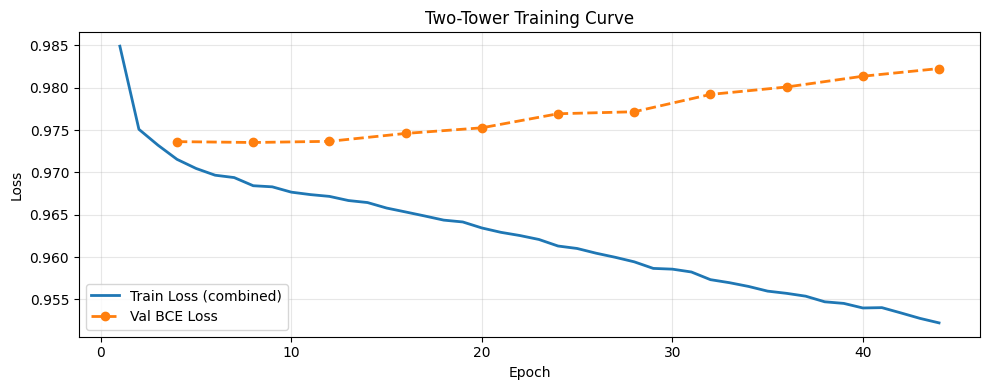

In [120]:
# %% ─── Cell 16: Visualizations ───────────────────────────────────────────────

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# OUT = "/mnt/user-data/outputs"
# os.makedirs(OUT, exist_ok=True)

# ── 16a. Training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, lw=2, label="Train Loss (combined)")
if val_losses:
    vx, vy = zip(*val_losses)
    ax.plot(vx, vy, "o--", lw=2, ms=6, label="Val BCE Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Two-Tower Training Curve"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

In [121]:
# ── 16b. Item2Vec co-occurrence heatmap (category-mean cosine similarity)
if i2v is not None:
    COURSE_NAMES = menu_df["course"].unique().tolist()
    course_vecs  = {}
    for cname in COURSE_NAMES:
        ids  = menu_df[menu_df.course == cname]["item_id"].tolist()
        vecs = [item2vec_matrix_normed[item_id_enc.transform([ii])[0]]
                for ii in ids if str(ii) in i2v.wv]
        if vecs:
            course_vecs[cname] = np.mean(vecs, axis=0)

    labels_ = list(course_vecs.keys())
    mat = np.array([[
        float(np.dot(course_vecs[a], course_vecs[b]) /
              (np.linalg.norm(course_vecs[a])*np.linalg.norm(course_vecs[b])+1e-9))
        for b in labels_] for a in labels_])

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(mat, cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels_))); ax.set_xticklabels(labels_, rotation = 30, ha = "right")
    ax.set_yticks(range(len(labels_))); ax.set_yticklabels(labels_)
    for i in range(len(labels_)):
        for j in range(len(labels_)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha = "center", va = "center", fontsize = 9)
    plt.colorbar(im, ax=ax)
    ax.set_title("Item2Vec Course Co-occurrence\n(higher = more often ordered together)")
    plt.tight_layout()
    plt.savefig("item2vec_cooc_heatmap.png", dpi=150)
    plt.show()


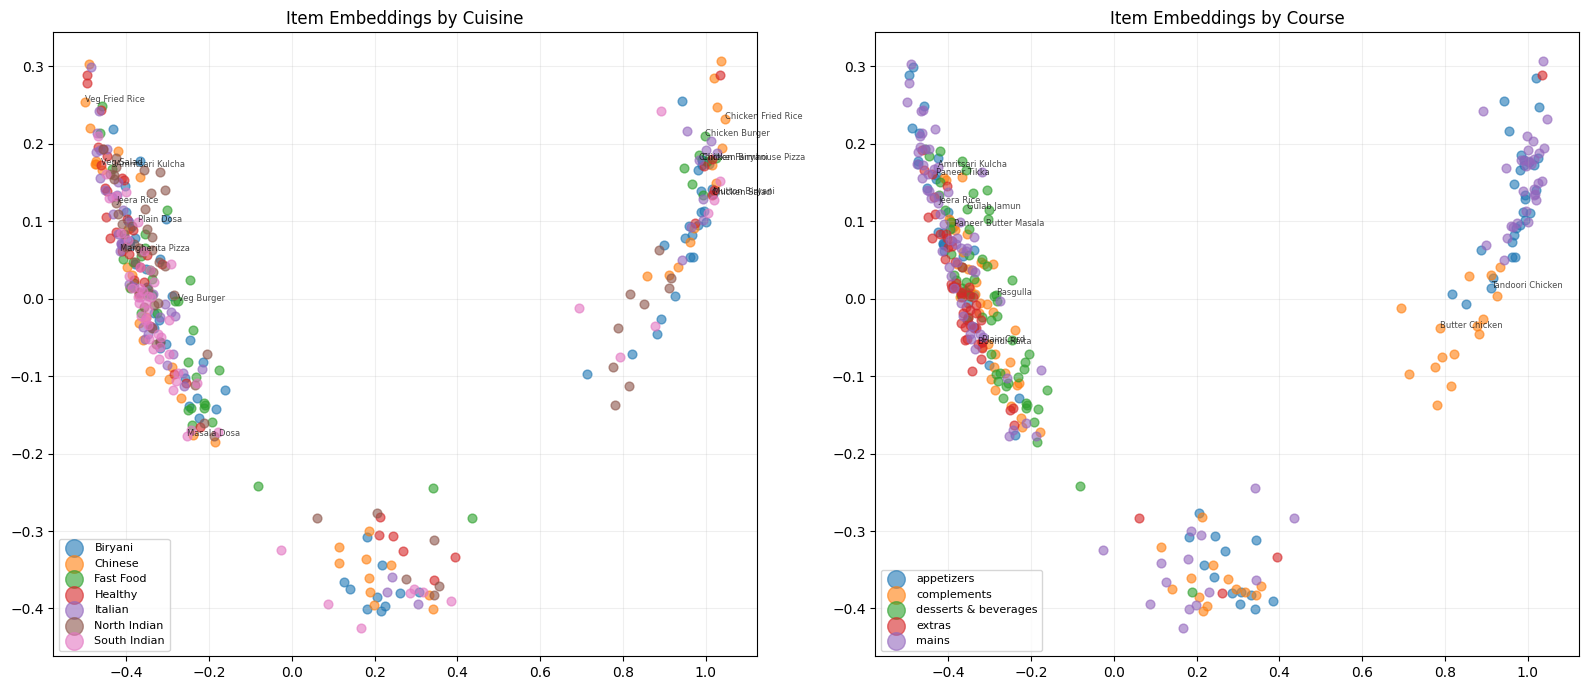

In [124]:
# ── 16c. PCA of final item embeddings coloured by course and cuisine
pca    = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(item_emb_final)
menu_plot = menu_df.copy()
menu_plot["PC1"] = coords[:, 0]
menu_plot["PC2"] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col in zip(axes, ["Cuisine", "Course"]):
    for val, grp in menu_plot.groupby(col):
        ax.scatter(grp["PC1"], grp["PC2"], label=val, alpha=0.6, s=40)
        # Annotate a few items per group
        for _, r in grp.head(2).iterrows():
            ax.annotate(r["Item Name"], (r["PC1"], r["PC2"]), fontsize = 6, alpha = 0.7)
    ax.set_title(f"Item Embeddings by {col.capitalize()}")
    ax.legend(fontsize = 8, markerscale = 2); ax.grid(alpha = 0.2)
plt.tight_layout()
plt.savefig("item_embeddings_pca.png", dpi=150)
plt.show()


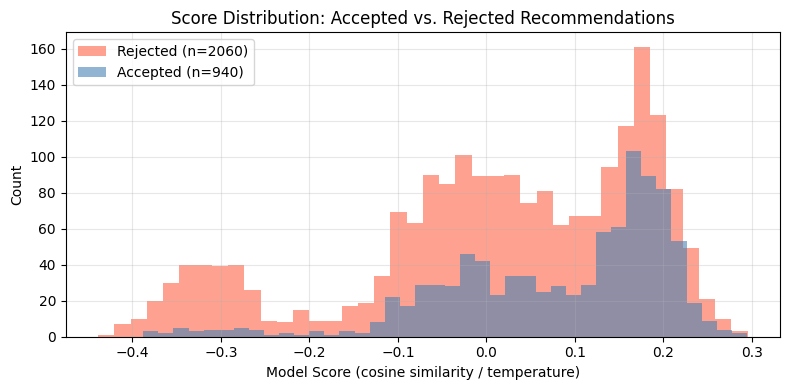

All plots saved.


In [125]:
# ── 16d. Acceptance rate analysis: did the model rank accepted items higher?
model.eval()
score_dist = {"accepted": [], "rejected": []}
for _, row in test_df.sample(3000, random_state=SEED).iterrows():
    iid = row["shown_item_id"]
    if iid not in ITEM_LOOKUP.index:
        continue
    c  = CUST_LOOKUP.loc[row["customer_id"]] if row["customer_id"] in CUST_LOOKUP.index else CUST_LOOKUP.iloc[0]
    u  = {
        "city_idx"     : torch.tensor([int(c["city_idx"])],    dtype=torch.long).to(CFG["DEVICE"]),
        "income_idx"   : torch.tensor([int(c["income_idx"])],  dtype=torch.long).to(CFG["DEVICE"]),
        "appusage_idx" : torch.tensor([int(c["appusage_idx"])],dtype=torch.long).to(CFG["DEVICE"]),
        "cuisine_pref" : torch.tensor([c["cuisine_pref_vec"]], dtype=torch.float32).to(CFG["DEVICE"]),
        "veg_vec"      : torch.tensor([c["veg_vec"]],          dtype=torch.float32).to(CFG["DEVICE"]),
        "price_scaled" : torch.tensor([float(c["price_scaled"])],    dtype=torch.float32).to(CFG["DEVICE"]),
        "avg_items_norm":torch.tensor([float(c["avg_items_norm"])],  dtype=torch.float32).to(CFG["DEVICE"]),
    }
    # ── In Cell 16d, replace cb dict with:
    cart_courses_16 = set(
        ITEM_META.get(iid, {}).get("course", "")
        for iid in row.get("cart_item_ids", [])
    )
    shown_course_16 = ITEM_META.get(iid, {}).get("course", "")

    cb = {
        "cart_emb"         : torch.tensor([row["cart_emb"]], dtype=torch.float32).to(CFG["DEVICE"]),
        "cart_size"        : torch.tensor([row["cart_size"]], dtype=torch.float32).to(CFG["DEVICE"]),
        "meal_time_idx"    : torch.tensor([float(MEAL_TIME_MAP.get(row["meal_time"], 0))], dtype=torch.float32).to(CFG["DEVICE"]),
        "hour_sin"         : torch.tensor([np.sin(2*np.pi*row["hour"]/24)], dtype=torch.float32).to(CFG["DEVICE"]),
        "hour_cos"         : torch.tensor([np.cos(2*np.pi*row["hour"]/24)], dtype=torch.float32).to(CFG["DEVICE"]),
        "has_mains"        : torch.tensor([float("mains"                in cart_courses_16)], dtype=torch.float32).to(CFG["DEVICE"]),
        "has_appetizers"   : torch.tensor([float("appetizers"           in cart_courses_16)], dtype=torch.float32).to(CFG["DEVICE"]),
        "has_complements"  : torch.tensor([float("complements"          in cart_courses_16)], dtype=torch.float32).to(CFG["DEVICE"]),
        "has_desserts_bev" : torch.tensor([float("desserts & beverages" in cart_courses_16)], dtype=torch.float32).to(CFG["DEVICE"]),
        "course_missing"   : torch.tensor([float(shown_course_16 not in cart_courses_16)], dtype=torch.float32).to(CFG["DEVICE"]),
    }
    it = ITEM_LOOKUP.loc[iid]
    f  = {
        "item_idx"   : torch.tensor([int(it["item_idx"])],    dtype=torch.long).to(CFG["DEVICE"]),
        "cuisine_idx": torch.tensor([int(it["cuisine_idx"])], dtype=torch.long).to(CFG["DEVICE"]),
        "course_idx" : torch.tensor([int(it["course_idx"])],  dtype=torch.long).to(CFG["DEVICE"]),
        "vegtype_idx": torch.tensor([int(it["vegtype_idx"])], dtype=torch.long).to(CFG["DEVICE"]),
        "is_veg"     : torch.tensor([float(it["is_veg"])],   dtype=torch.float32).to(CFG["DEVICE"]),
        "is_nonveg"  : torch.tensor([float(it["is_nonveg"])],dtype=torch.float32).to(CFG["DEVICE"]),
    }
    with torch.no_grad():
        q, i = model(u, cb, f)
        sc   = model.pointwise_score(q, i).item()
    bucket = "accepted" if row["label"] == 1 else "rejected"
    score_dist[bucket].append(sc)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(score_dist["rejected"], bins=40, alpha=0.6, label=f"Rejected (n={len(score_dist['rejected'])})", color="tomato")
ax.hist(score_dist["accepted"], bins=40, alpha=0.6, label=f"Accepted (n={len(score_dist['accepted'])})", color="steelblue")
ax.set_xlabel("Model Score (cosine similarity / temperature)")
ax.set_ylabel("Count")
ax.set_title("Score Distribution: Accepted vs. Rejected Recommendations")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150)
plt.show()
print("All plots saved.")


In [ ]:
# %% ─── Cell 15b: Comprehensive Evaluation Suite ─────────────────────────────
#
# Covers the key metrics across all three categories:
#   Model Performance : AUC, Precision@K, Recall@K, NDCG@K
#   Business Impact   : Acceptance Rate, AOV Lift (simulated), Baseline comparison
#   Operational       : Inference Latency, Coverage

import time
from sklearn.metrics import roc_auc_score

# ─────────────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def dcg_at_k(relevance, k):
    return sum(r / math.log2(i + 2) for i, r in enumerate(relevance[:k]))

def ndcg_at_k(recommended, relevant_set, k):
    relevance = [1 if x in relevant_set else 0 for x in recommended[:k]]
    ideal     = sorted(relevance, reverse=True)
    d         = dcg_at_k(relevance, k)
    id_       = dcg_at_k(ideal, k)
    return d / id_ if id_ > 0 else 0.0

def build_cart_b(row, iid, device):
    """Builds cart_b tensor dict for a single row — used across multiple eval functions."""
    cart_courses = set(
        ITEM_META.get(i, {}).get("course", "")
        for i in row.get("cart_item_ids", [])
    )
    shown_course = ITEM_META.get(iid, {}).get("course", "")
    return {
        "cart_emb"         : torch.tensor([row["cart_emb"]], dtype=torch.float32).to(device),
        "cart_size"        : torch.tensor([row["cart_size"]], dtype=torch.float32).to(device),
        "meal_time_idx"    : torch.tensor([float(MEAL_TIME_MAP.get(row["meal_time"], 0))], dtype=torch.float32).to(device),
        "hour_sin"         : torch.tensor([np.sin(2*np.pi*row["hour"]/24)], dtype=torch.float32).to(device),
        "hour_cos"         : torch.tensor([np.cos(2*np.pi*row["hour"]/24)], dtype=torch.float32).to(device),
        "has_mains"        : torch.tensor([float("mains"                in cart_courses)], dtype=torch.float32).to(device),
        "has_appetizers"   : torch.tensor([float("appetizers"           in cart_courses)], dtype=torch.float32).to(device),
        "has_complements"  : torch.tensor([float("complements"          in cart_courses)], dtype=torch.float32).to(device),
        "has_desserts_bev" : torch.tensor([float("desserts & beverages" in cart_courses)], dtype=torch.float32).to(device),
        "course_missing"   : torch.tensor([float(shown_course not in cart_courses)], dtype=torch.float32).to(device),
    }

def build_u(cid, device):
    """Builds user feature tensor dict for a single customer."""
    c = CUST_LOOKUP.loc[cid] if cid in CUST_LOOKUP.index else CUST_LOOKUP.iloc[0]
    return {
        "city_idx"       : torch.tensor([int(c["city_idx"])],         dtype=torch.long).to(device),
        "income_idx"     : torch.tensor([int(c["income_idx"])],       dtype=torch.long).to(device),
        "appusage_idx"   : torch.tensor([int(c["appusage_idx"])],     dtype=torch.long).to(device),
        "cuisine_pref"   : torch.tensor([c["cuisine_pref_vec"]],      dtype=torch.float32).to(device),
        "veg_vec"        : torch.tensor([c["veg_vec"]],               dtype=torch.float32).to(device),
        "price_scaled"   : torch.tensor([float(c["price_scaled"])],   dtype=torch.float32).to(device),
        "avg_items_norm" : torch.tensor([float(c["avg_items_norm"])], dtype=torch.float32).to(device),
    }

def build_f(iid, device):
    """Builds item feature tensor dict for a single item."""
    it = ITEM_LOOKUP.loc[iid] if iid in ITEM_LOOKUP.index else ITEM_LOOKUP.iloc[0]
    return {
        "item_idx"    : torch.tensor([int(it["item_idx"])],    dtype=torch.long).to(device),
        "cuisine_idx" : torch.tensor([int(it["cuisine_idx"])], dtype=torch.long).to(device),
        "course_idx"  : torch.tensor([int(it["course_idx"])],  dtype=torch.long).to(device),
        "vegtype_idx" : torch.tensor([int(it["vegtype_idx"])], dtype=torch.long).to(device),
        "is_veg"      : torch.tensor([float(it["is_veg"])],    dtype=torch.float32).to(device),
        "is_nonveg"   : torch.tensor([float(it["is_nonveg"])], dtype=torch.float32).to(device),
    }

def score_item(cid, row, iid):
    """Returns model score for a single (user, cart, item) triple."""
    u  = build_u(cid, CFG["DEVICE"])
    cb = build_cart_b(row, iid, CFG["DEVICE"])
    f  = build_f(iid, CFG["DEVICE"])
    with torch.no_grad():
        q, i = model(u, cb, f)
        return model.pointwise_score(q, i).item()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. MODEL PERFORMANCE METRICS
#    AUC, Precision@K, Recall@K, NDCG@K
#    Evaluated on the real exposure data — each order has 3 shown items
#    with explicit accept/reject labels.
#    K=1,2,3 since rail shows exactly 3 items.
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model_performance(test_df, n_eval=5000, k_values=(1, 2, 3)):
    model.eval()
    sample = test_df.sample(min(n_eval, len(test_df)), random_state=SEED)

    all_labels, all_scores = [], []
    per_order = {}   # order_group_idx → [(score, label), ...]

    for idx, (_, row) in enumerate(sample.iterrows()):
        cid = row["customer_id"]
        iid = row["shown_item_id"]
        if iid not in ITEM_LOOKUP.index:
            continue

        sc    = score_item(cid, row, iid)
        label = int(row["label"])
        all_labels.append(label)
        all_scores.append(sc)

        # Group every 3 rows as one order's recommendation set
        group = idx // 3
        if group not in per_order:
            per_order[group] = []
        per_order[group].append((sc, label))

    # ── AUC
    auc = roc_auc_score(all_labels, all_scores)

    # ── Per-order ranking metrics
    metrics = {k: {"precision": [], "recall": [], "ndcg": []} for k in k_values}

    for group, triplet in per_order.items():
        if len(triplet) != 3:
            continue
        ranked       = sorted(triplet, key=lambda x: x[0], reverse=True)
        ranked_labels= [lbl for _, lbl in ranked]
        relevant_set = {i for i, (_, lbl) in enumerate(ranked) if lbl == 1}
        n_relevant   = sum(ranked_labels)
        if n_relevant == 0:
            continue

        for k in k_values:
            top_k  = ranked_labels[:k]
            hits   = sum(top_k)
            metrics[k]["precision"].append(hits / k)
            metrics[k]["recall"   ].append(hits / n_relevant)
            metrics[k]["ndcg"     ].append(ndcg_at_k(
                [i for i, (sc,_) in enumerate(ranked)],
                relevant_set, k
            ))

    print("\n" + "="*60)
    print("MODEL PERFORMANCE METRICS")
    print("="*60)
    print(f"{'Metric':<28} " + "  ".join(f"K={k}" for k in k_values))
    print("-"*60)
    print(f"{'AUC':<28} {auc:.4f}")
    for metric in ["precision", "recall", "ndcg"]:
        vals = "     ".join(f"{np.mean(metrics[k][metric]):.4f}" for k in k_values)
        print(f"{metric.capitalize()+'@K':<28} {vals}")
    print(f"{'Random baseline NDCG':<28} " +
          "     ".join(f"{1/k:.4f}" for k in k_values))
    print("="*60)

    return {
        "auc"      : auc,
        "metrics"  : metrics,
        "k_values" : k_values,
    }

In [142]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. BUSINESS IMPACT METRICS
#    2a. Add-on Acceptance Rate — model recommendations vs random baseline
#    2b. AOV Lift — simulated incremental cart value from accepted add-ons
#    2c. Baseline comparison — popularity-based ranker vs TTE
# ─────────────────────────────────────────────────────────────────────────────

# ── Item price lookup (from menu + customers avg_per_item_value as proxy)
AVG_ITEM_PRICE = customers_df["avg_per_item_value"].mean()   # ~250 based on data

def popularity_rank(shown_ids):
    """
    Baseline ranker: rank by how often each item appears in orders
    (pure popularity, no personalization).
    """
    item_counts = orders_df.explode("Items Ordered ID")["Items Ordered ID"].value_counts()
    return sorted(shown_ids, key=lambda x: item_counts.get(x, 0), reverse=True)


def evaluate_business_impact(test_df, n_eval=5000):
    model.eval()

    # Group test examples into orders (every 3 rows = one order's shown set)
    sample  = test_df.sample(min(n_eval, len(test_df)), random_state=SEED)
    groups  = [sample.iloc[i:i+3] for i in range(0, len(sample)-2, 3)
               if len(sample.iloc[i:i+3]) == 3]

    tte_accepted, baseline_accepted = [], []
    tte_aov_lift, baseline_aov_lift = [], []

    for grp in groups:
        if grp["label"].sum() == 0:
            continue   # no positives in this order — skip for lift calc

        cid       = grp["customer_id"].iloc[0]
        shown_ids = grp["shown_item_id"].tolist()
        labels    = dict(zip(shown_ids, grp["label"].tolist()))

        # ── TTE ranking: score all 3 shown items and take top-1
        scores = {}
        for _, row in grp.iterrows():
            iid = row["shown_item_id"]
            if iid in ITEM_LOOKUP.index:
                scores[iid] = score_item(cid, row, iid)

        if not scores:
            continue

        tte_top1      = max(scores, key=scores.get)
        baseline_top1 = popularity_rank(shown_ids)[0]

        tte_accepted.append(labels.get(tte_top1, 0))
        baseline_accepted.append(labels.get(baseline_top1, 0))

        # ── AOV lift: if top-1 is accepted, cart value increases by item price
        tte_lift      = AVG_ITEM_PRICE * labels.get(tte_top1, 0)
        baseline_lift = AVG_ITEM_PRICE * labels.get(baseline_top1, 0)
        tte_aov_lift.append(tte_lift)
        baseline_aov_lift.append(baseline_lift)

    # ── Acceptance rate across all test examples (not just top-1)
    overall_acceptance = test_df["label"].mean()

    # ── Slot-level acceptance rates
    slot_rates = {}
    for slot in [0, 1, 2]:
        slot_df = test_df[test_df["slot"] == slot]
        slot_rates[slot+1] = slot_df["label"].mean()

    print("\n" + "="*60)
    print("BUSINESS IMPACT METRICS")
    print("="*60)
    print(f"{'Metric':<40} {'TTE':>8}  {'Baseline':>8}")
    print("-"*60)
    print(f"{'Add-on Acceptance Rate (top-1)':<40} "
          f"{np.mean(tte_accepted)*100:>7.1f}%  "
          f"{np.mean(baseline_accepted)*100:>7.1f}%")
    print(f"{'Simulated AOV Lift per order (₹)':<40} "
          f"{np.mean(tte_aov_lift):>8.1f}  "
          f"{np.mean(baseline_aov_lift):>8.1f}")
    print(f"{'Overall acceptance rate':<40} {overall_acceptance*100:>7.1f}%")
    print("-"*60)
    print("Acceptance rate by rail slot:")
    for slot, rate in slot_rates.items():
        print(f"  Slot {slot}: {rate*100:.1f}%")
    print("="*60)

    # ── Lift over baseline
    acc_lift = (np.mean(tte_accepted) - np.mean(baseline_accepted))
    aov_lift = (np.mean(tte_aov_lift) - np.mean(baseline_aov_lift))
    print(f"\nTTE vs Popularity baseline:")
    print(f"  Acceptance rate lift : +{acc_lift*100:.1f} percentage points")
    print(f"  AOV lift             : +₹{aov_lift:.1f} per order")

    return {
        "tte_acceptance_rate"     : np.mean(tte_accepted),
        "baseline_acceptance_rate": np.mean(baseline_accepted),
        "tte_aov_lift"            : np.mean(tte_aov_lift),
        "baseline_aov_lift"       : np.mean(baseline_aov_lift),
        "overall_acceptance_rate" : overall_acceptance,
        "slot_rates"              : slot_rates,
    }

In [143]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. OPERATIONAL METRICS
#    3a. Inference Latency — end-to-end time for get_recommendations()
#    3b. Coverage — % of test users/orders the model can serve
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_operational(test_df, n_latency=200):
    model.eval()
    sample = test_df.sample(min(n_latency, len(test_df)), random_state=SEED)

    # ── Latency: time full get_recommendations() call end-to-end
    latencies = []
    for _, row in sample.iterrows():
        cid  = row["customer_id"]
        cart = row.get("cart_item_ids", [])
        if not cart:
            continue
        start = time.perf_counter()
        try:
            _ = get_recommendations(cid, cart, order_hour=int(row["hour"]), top_n=3)
            latencies.append((time.perf_counter() - start) * 1000)  # ms
        except Exception:
            continue

    latencies = np.array(latencies)

    # ── Coverage: can the model serve a prediction for this user+cart?
    total, served = 0, 0
    for _, row in test_df.sample(min(2000, len(test_df)), random_state=SEED).iterrows():
        total += 1
        cid   = row["customer_id"]
        cart  = row.get("cart_item_ids", [])
        # Model can serve if: user exists in lookup AND cart has ≥1 known item
        user_known = cid in CUST_LOOKUP.index
        cart_known = any(iid in ITEM_LOOKUP.index for iid in cart)
        if user_known and cart_known:
            served += 1

    coverage = served / total if total > 0 else 0.0

    print("\n" + "="*60)
    print("OPERATIONAL METRICS")
    print("="*60)
    print(f"{'Inference Latency (ms)':<35}")
    print(f"  Mean    : {latencies.mean():.1f} ms")
    print(f"  Median  : {np.median(latencies):.1f} ms")
    print(f"  P95     : {np.percentile(latencies, 95):.1f} ms")
    print(f"  P99     : {np.percentile(latencies, 99):.1f} ms")
    print(f"  Max     : {latencies.max():.1f} ms")
    budget = 300  # ms SLA
    within_sla = (latencies < budget).mean() * 100
    print(f"  Within {budget}ms SLA : {within_sla:.1f}%")
    print(f"\n{'Coverage':<35}")
    print(f"  Requests served : {served}/{total} ({coverage*100:.1f}%)")
    print(f"  Cold-start gap  : {(1-coverage)*100:.1f}% (new users or unknown items)")
    print("="*60)

    return {
        "latency_mean_ms"  : latencies.mean(),
        "latency_p95_ms"   : np.percentile(latencies, 95),
        "latency_p99_ms"   : np.percentile(latencies, 99),
        "within_sla_pct"   : within_sla,
        "coverage"         : coverage,
    }

In [144]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. SEGMENT-LEVEL BREAKDOWN
#    Performance across veg preference and income segments
#    Shows model generalises across user types
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_segments(test_df, n_eval=4000):
    model.eval()
    sample = test_df.sample(min(n_eval, len(test_df)), random_state=SEED)

    results = []
    for _, row in sample.iterrows():
        cid = row["customer_id"]
        iid = row["shown_item_id"]
        if iid not in ITEM_LOOKUP.index or cid not in CUST_LOOKUP.index:
            continue

        c         = CUST_LOOKUP.loc[cid]
        sc        = score_item(cid, row, iid)
        dom_veg   = ["veg","nonveg","egg"][int(np.argmax(c["veg_vec"]))]
        income    = customers_df.loc[
            customers_df['Customer ID'] == cid, "Income Bracket"
        ].values[0] if cid in customers_df['Customer ID'].values else "unknown"

        results.append({
            "score"       : sc,
            "label"       : row["label"],
            "veg_segment" : dom_veg,
            "income"      : income,
            "meal_time"   : row["meal_time"],
        })

    results_df = pd.DataFrame(results)

    print("\n" + "="*60)
    print("SEGMENT-LEVEL AUC BREAKDOWN")
    print("="*60)

    for seg_col in ["veg_segment", "income", "meal_time"]:
        print(f"\nBy {seg_col}:")
        for seg_val, grp in results_df.groupby(seg_col):
            if grp["label"].nunique() < 2 or len(grp) < 50:
                continue
            seg_auc = roc_auc_score(grp["label"], grp["score"])
            print(f"  {str(seg_val):<20} AUC={seg_auc:.4f}  n={len(grp):,}")

    print("="*60)
    return results_df

In [145]:
# ─────────────────────────────────────────────────────────────────────────────
# RUN ALL EVALUATIONS
# ─────────────────────────────────────────────────────────────────────────────

print("Running comprehensive evaluation...\n")

model_metrics   = evaluate_model_performance(test_df, n_eval=5000, k_values=(1, 2, 3))
business_metrics= evaluate_business_impact  (test_df, n_eval=5000)
ops_metrics     = evaluate_operational      (test_df, n_latency=200)
segment_results = evaluate_segments         (test_df, n_eval=4000)

# ── Final summary card
print("\n" + "="*60)
print("EVALUATION SUMMARY CARD")
print("="*60)
print(f"  AUC                      : {model_metrics['auc']:.4f}")
print(f"  NDCG@3                   : {np.mean(model_metrics['metrics'][3]['ndcg']):.4f}")
print(f"  Precision@1              : {np.mean(model_metrics['metrics'][1]['precision']):.4f}")
print(f"  Recall@3                 : {np.mean(model_metrics['metrics'][3]['recall']):.4f}")
print(f"  Acceptance rate (TTE)    : {business_metrics['tte_acceptance_rate']*100:.1f}%")
print(f"  Acceptance rate (base)   : {business_metrics['baseline_acceptance_rate']*100:.1f}%")
print(f"  Simulated AOV lift       : ₹{business_metrics['tte_aov_lift'] - business_metrics['baseline_aov_lift']:.1f} vs baseline")
print(f"  Inference latency P95    : {ops_metrics['latency_p95_ms']:.1f} ms")
print(f"  Coverage                 : {ops_metrics['coverage']*100:.1f}%")
print("="*60)


Running comprehensive evaluation...


MODEL PERFORMANCE METRICS
Metric                       K=1  K=2  K=3
------------------------------------------------------------
AUC                          0.6127
Precision@K                  0.5639     0.5275     0.4728
Recall@K                     0.4073     0.7587     1.0000
Ndcg@K                       0.5639     0.7511     0.8169
Random baseline NDCG         1.0000     0.5000     0.3333

BUSINESS IMPACT METRICS
Metric                                        TTE  Baseline
------------------------------------------------------------
Add-on Acceptance Rate (top-1)              51.0%     50.3%
Simulated AOV Lift per order (₹)             71.2      70.2
Overall acceptance rate                     32.5%
------------------------------------------------------------
Acceptance rate by rail slot:
  Slot 1: 32.3%
  Slot 2: 32.8%
  Slot 3: 32.5%

TTE vs Popularity baseline:
  Acceptance rate lift : +0.7 percentage points
  AOV lift             : +₹1.0 p